In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
!pip install tensorflow 

%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Nishant Shekhar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

In [20]:
%pip install sklearn
from sklearn.model_selection import train_test_split

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [21]:
X = pd.read_csv('X.csv', index_col=0) # Or: X = pd.read_csv('X.csv').drop(columns=['Unnamed: 0'])y = pd.read_csv('y.csv')
y = pd.read_csv('y.csv')
print("X shape : " + str(X.shape))
print("y shape : " + str(y.shape))

X shape : (2893, 63637)
y shape : (2893, 1)


In [22]:
X_train, X_test_, y_train, y_test_ = train_test_split(
        X,
        y,
        test_size=0.4,
        random_state=42,
        stratify=y 
    )

X_cv , X_test, y_cv, y_test = train_test_split(X_test_, y_test_, test_size=0.5, random_state=42, stratify=y_test_)

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense
tf.keras.backend.clear_session()
model = Sequential([
    tf.keras.Input(shape=(63637, )), 
    Dense(units=1445, activation='relu'), 
    Dense(units=775, activation='relu'), 
    Dense(units=1, activation='sigmoid')
])

[layer1, layer2, layer3] = model.layers

In [27]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [28]:
history = model.fit(X_train, y_train, epochs=8, validation_data=(X_cv, y_cv))

Epoch 1/8


C:\Users\Nishant Shekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\backend\tensorflow\nn.py:1288: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7711 - loss: 0.6054

C:\Users\Nishant Shekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\backend\tensorflow\nn.py:1288: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 425ms/step - accuracy: 0.8202 - loss: 0.4882 - val_accuracy: 0.8325 - val_loss: 0.2631
Epoch 2/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 411ms/step - accuracy: 0.9089 - loss: 0.1577 - val_accuracy: 0.9534 - val_loss: 0.1181
Epoch 3/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 418ms/step - accuracy: 1.0000 - loss: 0.0461 - val_accuracy: 0.9931 - val_loss: 0.0434
Epoch 4/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 400ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.9965 - val_loss: 0.0276
Epoch 5/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 395ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9948 - val_loss: 0.0224
Epoch 6/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 412ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9965 - val_loss: 0.0198
Epoch 7/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 415ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9965 - val_loss: 0.0181
Epoch 8/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 408ms/step - accuracy: 1.0000 - loss: 9.0867e-04 - val_accuracy: 0.9965 -

Text(0, 0.5, 'Loss')

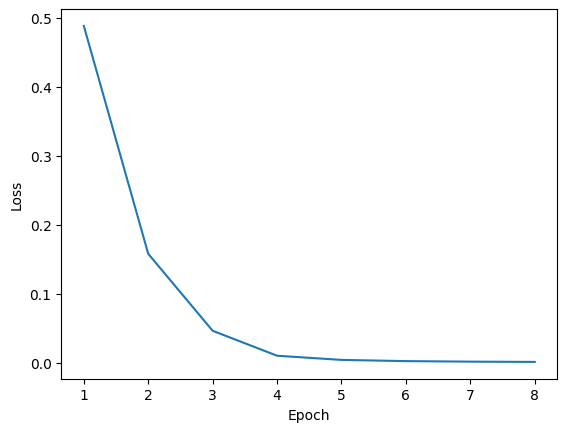

In [29]:
history.history['loss']
epoch = np.arange(8) + 1 
plt.plot(epoch , history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [30]:
m_loss, m_accurarcy = model.evaluate(X_test, y_test)
print("Loss : " + str(m_loss))
print("Accurarcy : " + str(m_accurarcy))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9965 - loss: 0.0190
Loss : 0.018977975472807884
Accurarcy : 0.9965457916259766


In [31]:
# Evaluation the model 
import sklearn
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_test_predicted = model.predict(X_test)
y_test_predicted[y_test_predicted > 0.3] = 1 
y_test_predicted = (y_test_predicted > 0.5).astype(int)

y_test_predicted = y_test_predicted.flatten()

cnf_mat = confusion_matrix(y_test, y_test_predicted)

recall = recall_score(y_test, y_test_predicted)
precision = precision_score(y_test, y_test_predicted)
f1 = f1_score(y_test, y_test_predicted)
print("Confusion Matrix : ", cnf_mat)
print("Recall Score : ", recall)
print("Precision Score : ", precision)
print("F1 Score : ", f1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Confusion Matrix :  [[483   0]
 [  1  95]]
Recall Score :  0.9895833333333334
Precision Score :  1.0
F1 Score :  0.9947643979057592


In [32]:
# roc and auc 
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_test_predicted)

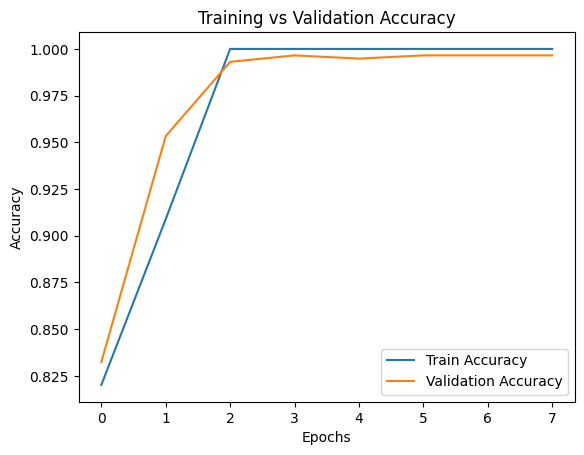

In [40]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

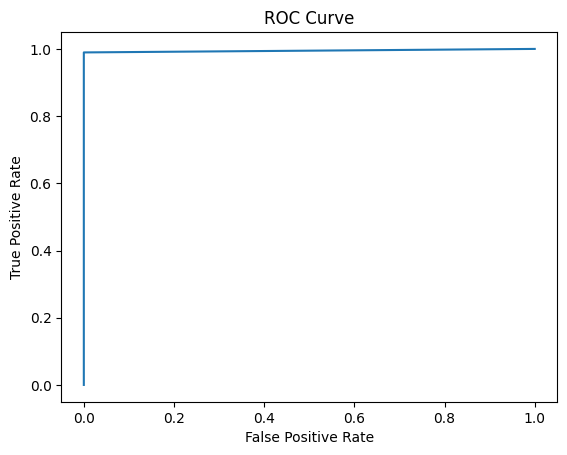

In [33]:
area = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [34]:
# Model is very confident at predicting true positive and differentiing too 

print(area) # Excellent 

0.9947916666666667


Text(0, 0.5, 'Precision')

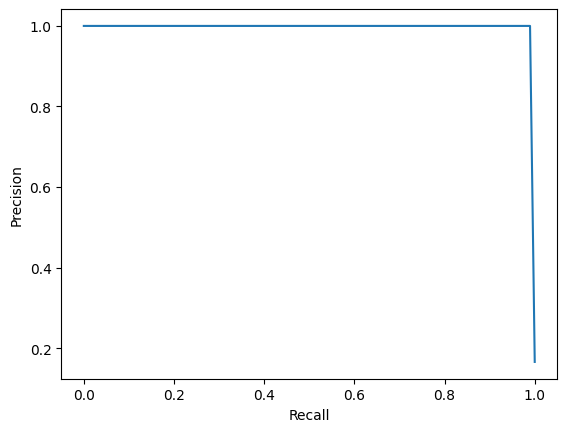

In [35]:
from sklearn.metrics import precision_recall_curve
precision_c , recall_c, thereshold_c = precision_recall_curve(y_test, y_test_predicted) 
plt.plot(recall_c, precision_c)
plt.xlabel("Recall")
plt.ylabel("Precision")

In [36]:
print(X_train.shape)

(1735, 63637)


In [37]:
model.save('spam_classifer_NN.keras')

In [41]:
import numpy as np
print("Test set distribution:")
print("Ham:", np.sum(y_test == 0))
print("Spam:", np.sum(y_test == 1))
print("Total:", len(y_test))

Test set distribution:
Ham: 0    483
dtype: int64
Spam: 0    96
dtype: int64
Total: 579


C:\Users\Nishant Shekhar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
